# 巴菲特质量代理 —— A 股年度回测

本 notebook 不把巴菲特的投资过程伪装成一个简单公式。由于当前离线数据中带公告日期的现金流量表只有 8 家，批量抓取 EBIT、净债务、资本投入和 owner earnings 会显著增加数据获取成本，且难以保证历史点时一致。本版使用可审计的低成本代理：5 年正盈利与增长、低盈利波动、ROE、低杠杆、流动性、合理估值、市值和行业安全门槛。

这检验的是"可持续质量 + 合理价格 + 低换手"，不是原始 EBIT/EV 神奇公式，也不是巴菲特完整的护城河、管理层和资本配置判断。

## 口径

- 信号在调仓日收盘形成，下一交易日成交；财报公告日期严格不晚于信号日。
- 每年 7 月调仓一次，20 只等权，单行业最多 3 只；回测持有到 `END`。
- 使用原始价格，分红按除权日显式入账，并按持有期扣除个人股息税，不使用前复权净值。
- 未知行业不绕过行业过滤；当前名称只能排除当前标记 ST，历史 ST 状态仍需后续接入点时证券状态数据。


In [1]:
import os, sys, warnings
import pandas as pd, numpy as np
warnings.filterwarnings('ignore')
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'graham_dodd.py')): break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT); sys.path.insert(0, _ROOT)
from strategy.graham_dodd import (load_universe, load_balance, load_profit, load_market,
    load_index, perf_metrics, END)
from strategy.buffett_quality import (annual_signal_dates, rank_candidates, build_ranking_map,
    audit_borderline, QualityBacktest, FUNNEL_BQ, N_HOLDINGS, EXCLUDED_INDUSTRIES,
    MIN_SIZE_QUANTILE)
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
INITIAL_CAPITAL = 1_000_000.0
print('质量代理参:', f'N_HOLDINGS={N_HOLDINGS}', f'MIN_SIZE=P{MIN_SIZE_QUANTILE:.0%}',
      f'行业排除{len(EXCLUDED_INDUSTRIES)}类', '单行业最多3只')


质量代理参: N_HOLDINGS=20 MIN_SIZE=P50% 行业排除18类 单行业最多3只


## 1. 数据现状核查

In [2]:
uni = load_universe()
has_bal = sum(1 for c in uni['code'] if load_balance(c) is not None)
has_pro = sum(1 for c in uni['code'] if load_profit(c) is not None)
has_mkt = sum(1 for c in uni['code'] if load_market(c, qfq=False) is not None)
signals = annual_signal_dates()
print(f'资产池(全部A股): {len(uni)} 只  (当前 {int((uni.kind=="current").sum())} / 退市 {int((uni.kind=="delisted").sum())})')
print(f'资产负债表覆盖: {has_bal} ({has_bal/len(uni):.1%})  利润表覆盖: {has_pro} ({has_pro/len(uni):.1%})')
print(f'行情覆盖(不复权): {has_mkt}  行业已知: {(uni.industry.fillna("") != "").sum()} ({((uni.industry.fillna("")) != "").mean():.1%})')
print(f'信号日(每年7月): {[d.date().isoformat() for d in signals]}')
print(f'可用现金流量表: {sum(os.path.exists(f"data/financial/{c}_cashflow.csv") for c in uni.code)} 家')
print('质量门槛: 近5年EPS均为正、CAGR>=5%、下滑<=1年、ROE>=15%、PE<=30、负债/权益<1、流动比率>=1')


资产池(全部A股): 5904 只  (当前 5543 / 退市 361)
资产负债表覆盖: 4283 (72.5%)  利润表覆盖: 4281 (72.5%)
行情覆盖(不复权): 4305  行业已知: 2900 (49.1%)
信号日(每年7月): ['2023-07-03', '2024-07-01', '2025-07-01', '2026-07-01']
可用现金流量表: 8 家
质量门槛: 近5年EPS均为正、CAGR>=5%、下滑<=1年、ROE>=15%、PE<=30、负债/权益<1、流动比率>=1


## 2. 首期质量池与点检对比

In [3]:
D = signals[0]; df = rank_candidates(D)
f = FUNNEL_BQ[D]
print(f'信号日 {D.date()}  市值门槛(质量候选市值P{MIN_SIZE_QUANTILE:.0%})={f["floor"]/1e8:.0f}亿')
print(f'  门槛漏斗: 可交易{f["tradable"]} → 排除ST{f["st"]} → '
      f'行业排除{f["industry"]} → 质量未过{f["quality"]} → '
      f'市值未过{f["size"]} → 终选{len(df)}只')
print(f'通过质量池 {len(df)} 只, Top{N_HOLDINGS} 名单与逐项指标:')
print(df.head(N_HOLDINGS).round(4).to_string(index=False))


信号日 2023-07-03  市值门槛(质量候选市值P50%)=180亿
  门槛漏斗: 可交易3930 → 排除ST176 → 行业排除2266 → 质量未过1456 → 市值未过16 → 终选16只
通过质量池 16 只, Top20 名单与逐项指标:
  code  name industry   market_cap      pe    roe  eps_cagr_5y  eps_declines_5y  debt_to_equity  current_ratio  rank_pe  rank_roe  rank_growth  composite
300390  天华新能     电子信息 2.272790e+10  9.9554 0.1816       1.0502                0          0.3985         2.9838      2.0      13.0          1.0       16.0
600873  梅花生物     食品行业 2.719964e+10  8.6277 0.2439       0.1970                1          0.8973         1.3057      1.0       5.0         12.0       18.0
600779   水井坊     酿酒行业 3.020515e+10 26.4430 0.3152       0.3749                1          0.9046         1.2517     12.0       1.0          7.0       20.0
600183  生益科技     电子器件 3.362103e+10 12.1473 0.1994       0.2462                1          0.6623         2.0029      4.0       9.0          9.0       22.0
000799   酒鬼酒     酿酒行业 3.140764e+10 27.3935 0.2575       0.5008                0          0.3666     

### 接近候选明细

以下为未入质量池但距门槛最近的标的 (按未达标项数从少到多), 逐项列出未达标原因。


In [4]:
for r in audit_borderline(D, top=12):
    print(f"{r['code']} {r['name']:8s} {r['industry']:6s} 价格{r['price']:8.2f}  未达标{r['n_fails']}项  [{', '.join(r['fails'])}]")


000026 飞亚达      商业百货   价格   12.14  未达标1项  [ROE 10.9%<15%]
000049 德赛电池     电器行业   价格   35.59  未达标1项  [负债/权益 1.70≥1]
000100 TCL科技    家电行业   价格    3.98  未达标1项  [负债/权益 4.86≥1]
000333 美的集团     家电行业   价格   59.06  未达标1项  [负债/权益 1.84≥1]
000425 徐工机械     机械行业   价格    6.71  未达标1项  [负债/权益 2.22≥1]
000529 广弘控股     食品行业   价格    6.38  未达标1项  [ROE 11.0%<15%]
000532 华金资本     电子信息   价格   11.09  未达标1项  [流动比率 0.75<1]
000568 泸州老窖     酿酒行业   价格  218.00  未达标1项  [PE 37.0>30]
000636 风华高科     电子器件   价格   15.45  未达标1项  [ROE 7.8%<15%]
000650 仁和药业     生物制药   价格    6.24  未达标1项  [ROE 11.3%<15%]
000676 智度股份     仪器仪表   价格    6.95  未达标1项  [近5年EPS不满足]
000690 宝新能源     电力行业   价格    7.19  未达标1项  [ROE 6.5%<15%]


## 3. 年度回测执行

In [5]:
ranking_map = build_ranking_map(signals, n=N_HOLDINGS)
bt = QualityBacktest(initial_capital=INITIAL_CAPITAL, n=N_HOLDINGS)
nav, trades, dates = bt.run(signals, ranking_map, end=pd.Timestamp(END))
print(f'回测完成: {len(trades)} 笔交易, 净值点数 {len(nav)}')
print(f'期末净值: {nav.iloc[-1]:,.2f} 元  ({(nav.iloc[-1]/INITIAL_CAPITAL-1):+.2%})')


  2023-07-04 候选16 买入15只
  2024-07-02 候选20 买入16只
  2025-07-02 候选20 买入14只
  2026-07-02 候选14 买入13只


回测完成: 103 笔交易, 净值点数 747
期末净值: 1,033,414.01 元  (+3.34%)


## 4. 每个阶段的调仓动作说明

下表按信号日列出: 质量池通过数、买入动作、股数与成交价、当季期末净值 (含成本)。

In [6]:
TRADE_COLS = ['date','code','name','action','shares','price','proceeds','fee','reason']
trades_df = pd.DataFrame(trades, columns=TRADE_COLS)
def period_table(D, bt):
    t = trades_df[trades_df['date'] == D]
    if t.empty:
        return pd.DataFrame()
    out = []
    for _, x in t.iterrows():
        out.append({'成交日': D.date(), '代码': x.code, '名称': x['name'],
                    '动作': ('买入' if x.action=='buy' else '卖出'),
                    '股数': int(x.shares) if x.shares and x.shares>0 else '—',
                    '成交价': f"{x.price:.2f}" if np.isfinite(x.price) else '—',
                    '金额': f"{x.proceeds:,.0f}",
                    '费用': f"{x.fee:.2f}",
                    '理由': x.reason})
    return pd.DataFrame(out)

lines = []
for D in signals:
    f = FUNNEL_BQ.get(D, {})
    p = next((p for p in bt.periods if p.get('signal_date') == D), None)
    execDay = p['date'] if p else None
    lines.append(f"### 信号日 {D.date()}" + (f" -> 成交 {execDay.date()}" if execDay is not None else ''))
    lines.append(f"- 通过质量池(市值门槛后): **{f.get('final_pool', 0)}** 只")
    names = '、'.join(f"{r['code']} {r['name']}" for _, r in ranking_map.get(D, pd.DataFrame()).iterrows()) or '无(全持币)'
    lines.append(f"- Top{N_HOLDINGS}: {names}")
    df = period_table(execDay, bt) if execDay is not None else pd.DataFrame()
    if df.empty:
        lines.append('- 本期无买卖调仓。')
    else:
        lines.append('')
        lines.append(df.to_string(index=False))
    navD = bt.nav_curve.get(execDay, np.nan) if execDay is not None else np.nan
    lines.append(f"- 当季期末净值: {navD:,.2f} 元 `(`现金或持仓市值合计`)`" if np.isfinite(navD) else '- 当季期末净值: (无)')
    lines.append('')
print('\n'.join(lines))


### 信号日 2023-07-03 -> 成交 2023-07-04
- 通过质量池(市值门槛后): **16** 只
- Top20: 300390 天华新能、600873 梅花生物、600779 水井坊、600183 生益科技、000799 酒鬼酒、000661 长春高新、002555 三七互娱、002415 海康威视、600702 舍得酒业、002032 苏 泊 尔、601888 中国中免、002001 新 和 成、002557 洽洽食品、000858 五 粮 液、000733 振华科技、002463 沪电股份

       成交日     代码  名称 动作   股数    成交价     金额    费用            理由
2023-07-04 300390   0 买入 1700  35.43 60,231 18.67 巴菲特质量代理 Top20
2023-07-04 600873   1 买入 7000   8.91 62,370 19.33 巴菲特质量代理 Top20
2023-07-04 600779   2 买入 1000  61.76 61,760 19.15 巴菲特质量代理 Top20
2023-07-04 600183   3 买入 4200  14.76 61,992 19.22 巴菲特质量代理 Top20
2023-07-04 000799   4 买入  600  96.74 58,044 17.99 巴菲特质量代理 Top20
2023-07-04 000661   5 买入  400 144.32 57,728 17.90 巴菲特质量代理 Top20
2023-07-04 002555   6 买入 1900  32.66 62,054 19.24 巴菲特质量代理 Top20
2023-07-04 002415   7 买入 1800  34.59 62,262 19.30 巴菲特质量代理 Top20
2023-07-04 600702   8 买入  400 130.00 52,000 16.12 巴菲特质量代理 Top20
2023-07-04 002032   9 买入 1200  51.99 62,388 19.34 巴菲特质量代理 Top20
2023-07-04 601888  10 买入  500 11

## 5. 防御性校验: 门槛漏斗 · 行业分布

**(a) 门槛漏斗** 与 **(b) 持仓行业分布** 逐期核查, 避免单一行业/主题堆积。

In [7]:
# (a) 门槛漏斗: 每个信号日一次全市场扫描的统计数据
funnel = pd.DataFrame([{'日期': d.date(), '可交易': FUNNEL_BQ.get(d, {}).get('tradable', 0),
                        '排除ST': FUNNEL_BQ.get(d, {}).get('st', 0),
                        '行业排除': FUNNEL_BQ.get(d, {}).get('industry', 0),
                        '质量未过': FUNNEL_BQ.get(d, {}).get('quality', 0),
                        '市值未过': FUNNEL_BQ.get(d, {}).get('size', 0),
                        '终选池': FUNNEL_BQ.get(d, {}).get('final_pool', 0)} for d in signals])
print('门槛漏斗 (各信号日通过数):')
print(funnel.to_string(index=False))


门槛漏斗 (各信号日通过数):
        日期  可交易  排除ST  行业排除  质量未过  市值未过  终选池
2023-07-03 3930   176  2266  1456    16   16
2024-07-01 4039   177  2373  1449    20   20
2025-07-01 4106   176  2441  1448    20   21
2026-07-01 4160   176  2452  1505    13   14


In [8]:
# (b) 持仓行业分布 (每信号日, 按投资市值的前 5 行业)
for p in bt.periods:
    mark = bt.nav_curve.get(p['date'], np.nan)
    inds = sorted((k for k in p['industry'].items() if k[0]), key=lambda kv: -kv[1])[:5]
    share = f"{sum(v for _, v in inds) / mark:.0%}" if np.isfinite(mark) and mark > 0 else '—'
    top = '、'.join(f"{k}({v / mark:.0%})" for k, v in inds) if np.isfinite(mark) and mark > 0 else '·'
    print(f"{p['date'].date()}: 前5行业占净值 {share}  -> {top}")


2023-07-04: 前5行业占净值 66%  -> 电子器件(18%)、酿酒行业(17%)、食品行业(12%)、生物制药(12%)、家电行业(6%)
2024-07-02: 前5行业占净值 56%  -> 电子器件(14%)、生物制药(14%)、酿酒行业(13%)、机械行业(10%)、汽车制造(5%)
2025-07-02: 前5行业占净值 47%  -> 酿酒行业(13%)、生物制药(10%)、电子器件(10%)、机械行业(9%)、汽车制造(5%)
2026-07-02: 前5行业占净值 70%  -> 机械行业(21%)、电子信息(14%)、生物制药(14%)、酿酒行业(14%)、服装鞋类(7%)


## 6. 净值曲线与基准对比

In [9]:
base = nav / INITIAL_CAPITAL
bench = {}
for label, code_ in [('沪深300','000300'), ('中证800','000906')]:
    x = load_index(code_).loc[base.index[0]:base.index[-1], 'close']; bench[label] = x / x.iloc[0]
comp = pd.DataFrame({'巴菲特质量代理(含成本)': base, **bench}).ffill().dropna(subset=['巴菲特质量代理(含成本)'])
comp.tail(8).round(4)


,巴菲特质量代理(含成本),沪深300,中证800
2026-07-22,0.9784,1.2099,1.2288
2026-07-23,0.9802,1.2126,1.2301
2026-07-24,0.9596,1.1924,1.2065
2026-07-27,0.9699,1.2061,1.2246
2026-07-28,0.9769,1.1720,1.1875
2026-07-29,1.0093,1.1799,1.1968
2026-07-30,1.0308,1.1669,1.1781
2026-07-31,1.0334,1.1768,1.1932


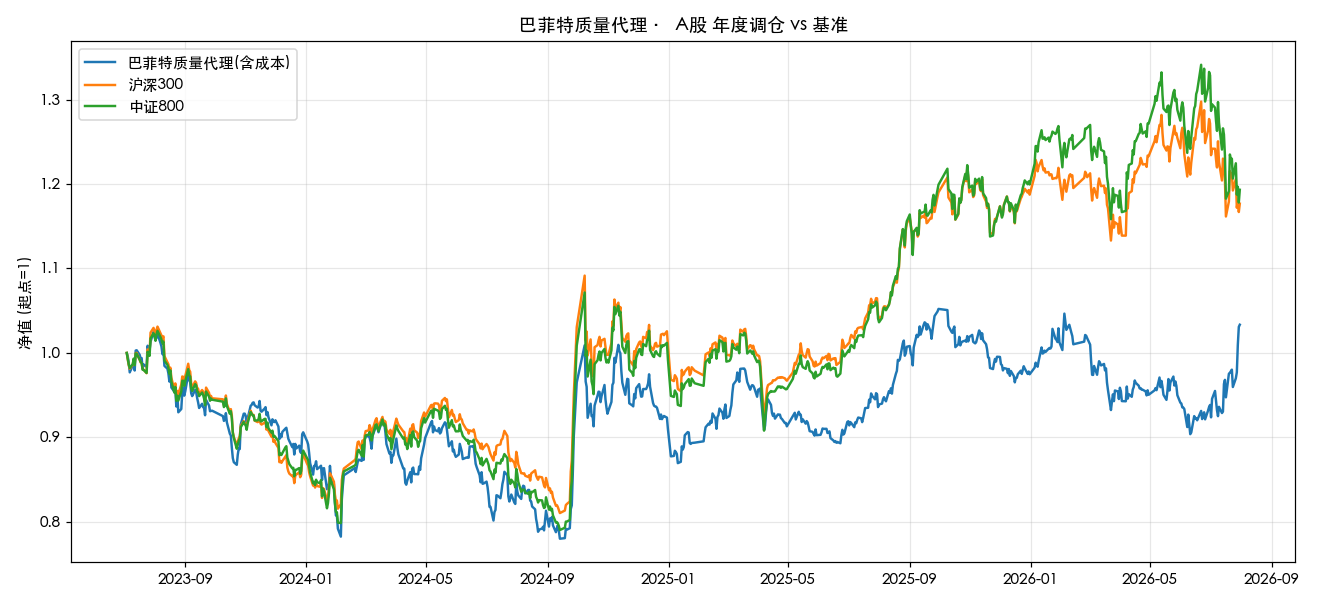

净值对比图: reports/generated/magic_formula/nav_compare.png


In [10]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('reports/generated/magic_formula', exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 5.5))
for c in comp.columns:
    ax.plot(comp[c], label=c, linewidth=1.6)
ax.set_title('巴菲特质量代理 · A股 年度调仓 vs 基准')
ax.set_ylabel('净值 (起点=1)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
img = 'reports/generated/magic_formula/nav_compare.png'
fig.savefig(img, dpi=110)
plt.close(fig)
comp.to_csv('reports/generated/magic_formula/nav_compare.csv')
display(Image(filename=img))
print('净值对比图: reports/generated/magic_formula/nav_compare.png')


## 7. 绩效口径

In [11]:
m = perf_metrics(nav)
labels = {'total_return':'累计收益','annual_return':'年化收益','annual_vol':'年化波动',
          'sharpe':'夏普','max_drawdown':'最大回撤','win_rate':'日胜率'}
print(f"{'期末权益':<12} {nav.iloc[-1]:,.0f} 元")
order = ['total_return','annual_return','annual_vol','sharpe','max_drawdown','win_rate']
for k in order:
    v = m.get(k)
    if k in ('total_return','annual_return','annual_vol','max_drawdown'):
        print(f"{labels[k]:<12} {v:+.2%}")
    else:
        print(f"{labels[k]:<12} {v:+.4f}")
print(f"{'调仓次数':<12} {len(dates)}")
print(f"{'交易笔数':<12} {len(trades_df)}  (买 {len(trades_df[trades_df.action=='buy'])}, 卖 {len(trades_df[trades_df.action=='sell'])})")
print(f"{'持仓期占比':<12} {(bt.holdings_curve>0).mean():.1%}")
buys = trades_df[trades_df['action']=='buy']['proceeds'].sum()
print(f"{'累计买入金额':<12} {buys:,.0f} 元")


期末权益         1,033,414 元
累计收益         +3.37%
年化收益         +1.08%
年化波动         +17.98%
夏普           -0.0509
最大回撤         -23.92%
日胜率          +0.4853
调仓次数         4
交易笔数         103  (买 58, 卖 45)
持仓期占比        100.0%
累计买入金额       2,987,575 元


## 8. 结论与局限

当前版本优先保证点时、低换手和可复现。真正接近巴菲特还需要逐期现金流量表、资本开支、净现金/有息负债、扣非利润、护城河和管理层/治理变量。建议先对少量候选公司补抓这些字段，再做增量实验，不要把全市场缺失数据默认为零。